2026/06/30 04:00:50 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '3dce2413e93249388bf21a0ab5b6f8e6', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/06/30 04:00:50 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/06/30 04:00:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/30 04:00:50 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


Applying SMOTE geometric interpolation


2026/06/30 04:00:53 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


Training sequential trees (XGBoost)
Pipeline training completed successfully

--- Classification Report (45% Threshold) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.74      0.86      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.93      0.90     56962
weighted avg       1.00      1.00      1.00     56962

PR-AUC Score: 0.8774


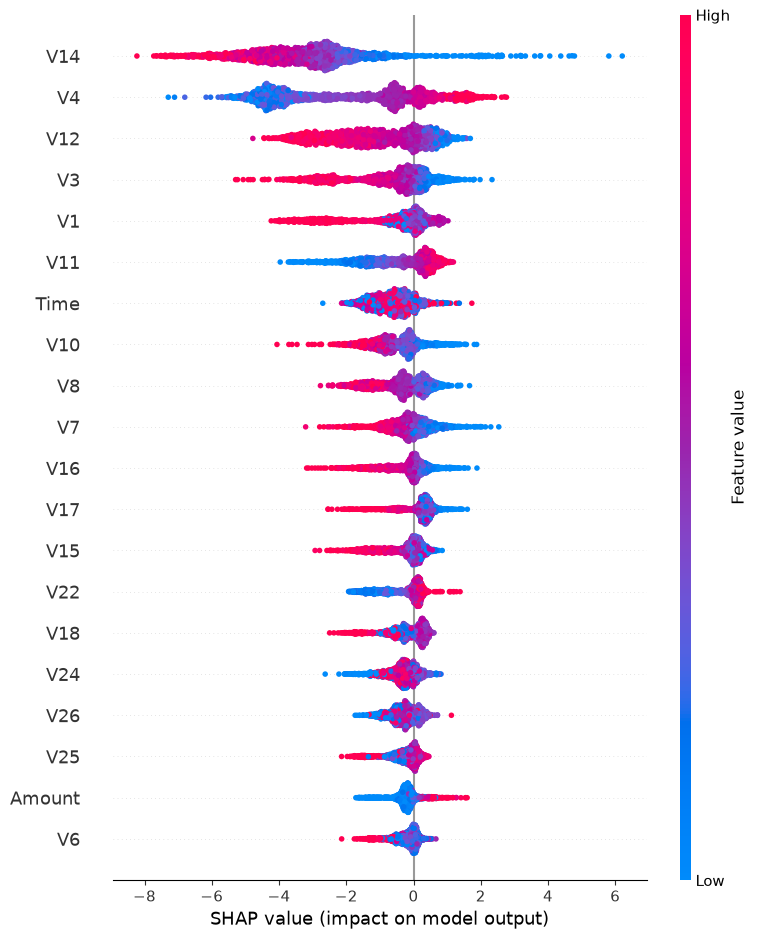

['fraud_detector_model.pkl']

In [39]:
import pandas as pd
import joblib
import shap
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve, auc

class FraudDetectionModel :
    def __init__(self, random_state=42) :
        self.random_state = random_state
        self.model = XGBClassifier(random_state=random_state, eval_metric='logloss')
        self.smote = SMOTE(random_state=random_state)

    def fit_resample(self, X_train, y_train) :
        """Applies SMOTE and trains the XGBoost Model"""
        print("Applying SMOTE geometric interpolation")
        X_train_res , y_train_res = self.smote.fit_resample(X_train, y_train)

        print("Training sequential trees (XGBoost)")
        self.model.fit(X_train_res, y_train_res)
        print("Pipeline training completed successfully")

    def predict_proba(self, X_test) :
        """Returns raw probabilities of fraud transactions (Class 1)"""
        return self.model.predict_proba(X_test)[:, 1]

    def evaluate(self, X_test, y_test) :
        """Evaluates model using PR-AUC and a classification report."""
        y_pred_proba = self.predict_proba(X_test)

        custom_threshold = 0.45
        y_pred = (y_pred_proba >= custom_threshold).astype(int)

        print(f"\n--- Classification Report ({int(custom_threshold*100)}% Threshold) ---")
        print(classification_report(y_test, y_pred))

        precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
        pr_auc_score = auc(recall, precision)

        print(f"PR-AUC Score: {pr_auc_score:.4f}")
        return pr_auc_score


df = pd.read_csv("creditcard.csv")
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = FraudDetectionModel()

pipeline.fit_resample(X_train, y_train)

pipeline.evaluate(X_test, y_test)

shap.initjs()

explainer = shap.TreeExplainer(pipeline.model)

X_test_sample = X_test.sample(n=2000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

shap.summary_plot(shap_values, X_test_sample)

joblib.dump(pipeline, 'fraud_detector_model.pkl')

In [26]:
import sklearn
import xgboost
import pandas

print(f"Scikit-Learn version: {sklearn.__version__}")
print(f"XGBoost version: {xgboost.__version__}")
print(f"Pandas version: {pandas.__version__}")

Scikit-Learn version: 1.9.0
XGBoost version: 3.3.0
Pandas version: 3.0.3


In [27]:
import sys
print(sys.executable)
print(sys.path)

/Users/dk/Desktop/fraud-detection-mle/venv/bin/python3
['/opt/homebrew/Cellar/python@3.12/3.12.12/Frameworks/Python.framework/Versions/3.12/lib/python312.zip', '/opt/homebrew/Cellar/python@3.12/3.12.12/Frameworks/Python.framework/Versions/3.12/lib/python3.12', '/opt/homebrew/Cellar/python@3.12/3.12.12/Frameworks/Python.framework/Versions/3.12/lib/python3.12/lib-dynload', '', '/Users/dk/Desktop/fraud-detection-mle/venv/lib/python3.12/site-packages']



Starting MLflow tracking run...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END xgb__colsample_bytree=1.0, xgb__learning_rate=0.2, xgb__max_depth=3, xgb__n_estimators=200, xgb__subsample=0.8; total time=   1.1s
[CV] END xgb__colsample_bytree=1.0, xgb__learning_rate=0.2, xgb__max_depth=3, xgb__n_estimators=200, xgb__subsample=0.8; total time=   1.0s
[CV] END xgb__colsample_bytree=1.0, xgb__learning_rate=0.2, xgb__max_depth=3, xgb__n_estimators=200, xgb__subsample=0.8; total time=   1.0s
[CV] END xgb__colsample_bytree=0.8, xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=300, xgb__subsample=0.8; total time=   1.4s
[CV] END xgb__colsample_bytree=0.8, xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=300, xgb__subsample=0.8; total time=   1.4s
[CV] END xgb__colsample_bytree=0.8, xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=300, xgb__subsample=0.8; total time=   1.4s
[CV] END xgb__colsample_bytree=0.8, xgb__learning_rate=0.1, xgb

2026/06/30 03:01:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/Users/dk/Desktop/fraud-detection-mle/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:3424: FutureWarning: `y_pred` was renamed to `y_proba` in version 1.9 and will be removed in 1.11. Use `y_proba` instead.
  warnings.warn(
2026/06/30 03:01:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https:/


--- TUNING COMPLETE ---
Final Test AUPRC Score: 0.8841
Optimal Threshold: 0.4500
At this threshold -> Precision: 0.7328 | Recall: 0.8673
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.73      0.87      0.79        98

    accuracy                           1.00     56962
   macro avg       0.87      0.93      0.90     56962
weighted avg       1.00      1.00      1.00     56962



/Users/dk/Desktop/fraud-detection-mle/venv/lib/python3.12/site-packages/sklearn/utils/_plotting.py:193: FutureWarning: `**kwargs` is deprecated and will be removed in 1.11. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


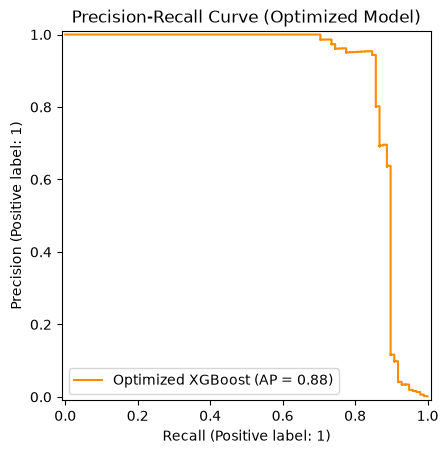

In [38]:
#Tuning the hyperparameters of the model
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import mlflow
import mlflow.sklearn
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay, classification_report, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np
from imblearn.pipeline import Pipeline as ImbPipeline

# SMOTE + XGBoost as a single pipeline — SMOTE runs inside each fold
imb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb',   xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1))
])

param_grid = {
    'xgb__learning_rate':  [0.01, 0.05, 0.1, 0.2],
    'xgb__max_depth':      [3, 5, 7, 9],
    'xgb__n_estimators':   [50, 100, 200, 300],
    'xgb__subsample':      [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0],
}

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=imb_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring='average_precision',
    cv=cv_strategy,
    verbose=2,
    random_state=42,
    n_jobs=1
)

#---- MLFlow tracking ----------
mlflow.sklearn.autolog()

print("\nStarting MLflow tracking run...")

with mlflow.start_run(run_name="XGBoost Random Search + SMOTE"):
    random_search.fit(X_train, y_train)
    optimized_model = random_search.best_estimator_

    y_pred_proba = optimized_model.predict_proba(X_test)[:, 1]
    test_auprc = average_precision_score(y_test, y_pred_proba)

    # ── Recall-first threshold (catches at least 90% of frauds) ──
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
    
    
    optimal_threshold = 0.45       # flag transaction only if model is >= 34% sure it's fraud
    idx = np.searchsorted(thresholds, optimal_threshold)
    optimal_precision = precisions[idx]
    optimal_recall    = recalls[idx]

    # ── Logging everything to MLflow ──
    for param_name, param_value in random_search.best_params_.items():
        mlflow.log_param(param_name, param_value)
    mlflow.log_param("optimal_threshold", optimal_threshold)
    mlflow.log_metric("test_auprc", test_auprc)

#---- MLFlow tracking ends -----------



# ── Results ───────────────────────────────────────────────────────
print("\n--- TUNING COMPLETE ---")
print(f"Final Test AUPRC Score: {test_auprc:.4f}")
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"At this threshold -> Precision: {optimal_precision:.4f} | Recall: {optimal_recall:.4f}")

y_pred = (y_pred_proba_final >= optimal_threshold).astype(int)
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

display = PrecisionRecallDisplay.from_estimator(
    optimized_model, X_test, y_test, name="Optimized XGBoost", color="darkorange"
)
_ = display.ax_.set_title("Precision-Recall Curve (Optimized Model)")
plt.show()